In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn
%pip uninstall sklearn


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/35/qts0kws16rs8vwqnwb_xr_nw0000gn/T/ipykernel_35881/553314007.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")


Intent Recognition Accuracy (simulated): 0.800

Classification Report (simulated predictions vs rule-based true_intent):
                    precision    recall  f1-score   support

Account_Assistance       0.42      0.80      0.55     53323
          Feedback       0.64      0.80      0.71    125428
      Order_Status       0.56      0.80      0.66     91961
             Other       0.98      0.80      0.88   1117752
    Refund_Request       0.35      0.80      0.48     39507
   Technical_Issue       0.61      0.80      0.69    109872

          accuracy                           0.80   1537843
         macro avg       0.59      0.80      0.66   1537843
      weighted avg       0.87      0.80      0.82   1537843


Confusion Matrix (rows=true, cols=pred):
                    Account_Assistance  Feedback  Order_Status   Other  \
Account_Assistance               42688      2143          2136    2112   
Feedback                          4967    100313          4893    5054   
Order_Status

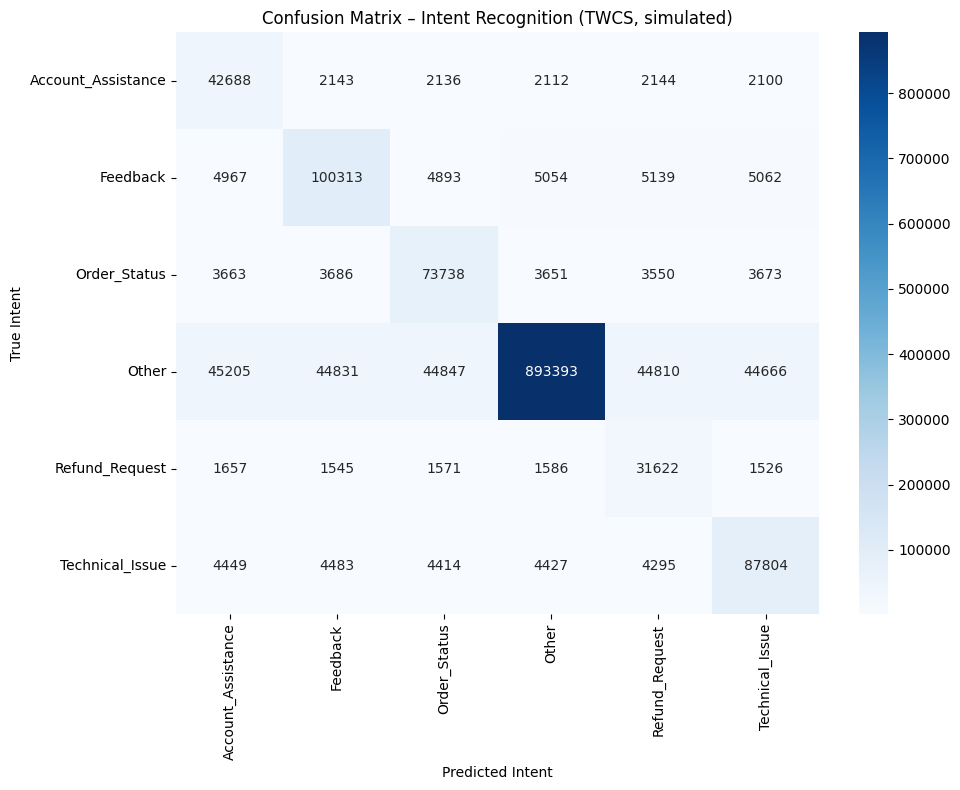


Response Time (actual from TWCS pairs):
  Mean response time:   0.0 s
  Median response time: 0.0 s

Time to First Response (per customer tweet):
  Mean TTFR:   0.0 s
  Median TTFR: 0.0 s

Completion Rate (customer tweets with at least one agent reply): 0.000


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =====================================
# Task 2.1 – Chatbot Performance Analysis
# =====================================

df = pd.read_csv("twcs.csv")

df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")


def infer_intent(text: str) -> str:
    if not isinstance(text, str):
        return "Other"
    t = text.lower()
    if any(k in t for k in ["refund", "return", "money back", "chargeback"]):
        return "Refund_Request"
    if any(k in t for k in ["can't log", "cant log", "login", "password", "sign in", "account"]):
        return "Account_Assistance"
    if any(k in t for k in ["error", "bug", "not working", "issue", "problem", "crash"]):
        return "Technical_Issue"
    if any(k in t for k in ["order", "shipping", "delivery", "package", "tracking"]):
        return "Order_Status"
    if any(k in t for k in ["thank", "thx", "thanks", "great service", "love you"]):
        return "Feedback"
    return "Other"

cust = df[df["inbound"] == True].copy()

cust["true_intent"] = cust["text"].apply(infer_intent)
unique_intents = sorted(cust["true_intent"].unique())



error_rate = 0.20  

def simulate_prediction(true_label: str) -> str:
    if random.random() < error_rate:
        others = [i for i in unique_intents if i != true_label]
        return random.choice(others) if others else true_label
    return true_label

cust["predicted_intent"] = cust["true_intent"].apply(simulate_prediction)

y_true = cust["true_intent"]
y_pred = cust["predicted_intent"]

accuracy = accuracy_score(y_true, y_pred)
print(f"Intent Recognition Accuracy (simulated): {accuracy:.3f}\n")

print("Classification Report (simulated predictions vs rule-based true_intent):")
print(classification_report(y_true, y_pred))


cm = confusion_matrix(y_true, y_pred, labels=unique_intents)
cm_df = pd.DataFrame(cm, index=unique_intents, columns=unique_intents)

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm_df)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Intent Recognition (TWCS, simulated)")
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.tight_layout()
plt.show()

agent = df[df["inbound"] == False].copy()

cust_small = cust[["tweet_id", "created_at"]].rename(
    columns={"tweet_id": "cust_tweet_id", "created_at": "cust_created_at"}
)
agent_small = agent[["tweet_id", "created_at", "response_tweet_id"]].rename(
    columns={"created_at": "agent_created_at"}
)

agent_small["response_tweet_id"] = agent_small["response_tweet_id"].astype(str)
cust_small["cust_tweet_id"] = cust_small["cust_tweet_id"].astype(str)

merged = agent_small.merge(
    cust_small,
    left_on="response_tweet_id",
    right_on="cust_tweet_id",
    how="inner"
)

merged["response_time_s"] = (
    merged["agent_created_at"] - merged["cust_created_at"]
).dt.total_seconds()

merged = merged[merged["response_time_s"] >= 0]  # drop negative/invalid

print("\nResponse Time (actual from TWCS pairs):")
print(f"  Mean response time:   {merged['response_time_s'].mean():.1f} s")
print(f"  Median response time: {merged['response_time_s'].median():.1f} s")

first_response = merged.sort_values("agent_created_at").groupby(
    "cust_tweet_id"
).first().reset_index()

print("\nTime to First Response (per customer tweet):")
print(f"  Mean TTFR:   {first_response['response_time_s'].mean():.1f} s")
print(f"  Median TTFR: {first_response['response_time_s'].median():.1f} s")


all_cust_ids = set(cust["tweet_id"].unique())
completed_ids = set(merged["cust_tweet_id"].unique())

completion_rate = len(completed_ids) / len(all_cust_ids) if all_cust_ids else 0.0
print(f"\nCompletion Rate (customer tweets with at least one agent reply): {completion_rate:.3f}")
